# 11 — Model 4: Decline Classifier (XGBoost Binary Classification)

**Tujuan:** Menjawab pertanyaan inti project ini — **"Apakah video ini akan/sedang mengalami penurunan views?"**  
**Target:** `is_declining` (views_trend_ratio < 0.90) — distribusi seimbang: 50.9% declining / 49.1% normal  
**Algoritma:** XGBoost Classifier + threshold tuning + SHAP + probability score  
**Output:**
- `backend/models/model4_decline_classifier.pkl`
- `backend/scalers/scaler_model4.pkl`
- `backend/models/model4_threshold.pkl` (optimal probability threshold)
- `data/processed/model_output_decline.csv`

**Catatan:** Model ini adalah yang paling langsung menjawab business problem 'diagnosa penurunan views'

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib, os, warnings
warnings.filterwarnings('ignore')

from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    precision_recall_curve, auc, average_precision_score,
    f1_score, precision_score, recall_score, roc_curve
)
import shap

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
print('Libraries loaded ✓')

Libraries loaded ✓


In [2]:
# ── 1. LOAD DATA ──────────────────────────────────────────────────────────────
fm = pd.read_csv('../../data/processed/features_merged.csv')
abis = pd.read_csv('../../data/cleaned/abis_cleaning.csv')[['video_id', 'ts1_views']]

df = fm.merge(abis, on='video_id', how='inner').dropna(subset=['ts1_views']).reset_index(drop=True)
df['ts1_views'] = df['ts1_views'].fillna(0)

print(f'Shape: {df.shape}')
print(f'\nTarget distribution (is_declining):')
print(df['is_declining'].value_counts(normalize=True).round(3))
print(f'\nTotal declining videos: {df["is_declining"].sum()} / {len(df)}')

Shape: (2351, 57)

Target distribution (is_declining):
is_declining
1    0.509
0    0.491
Name: proportion, dtype: float64

Total declining videos: 1197 / 2351


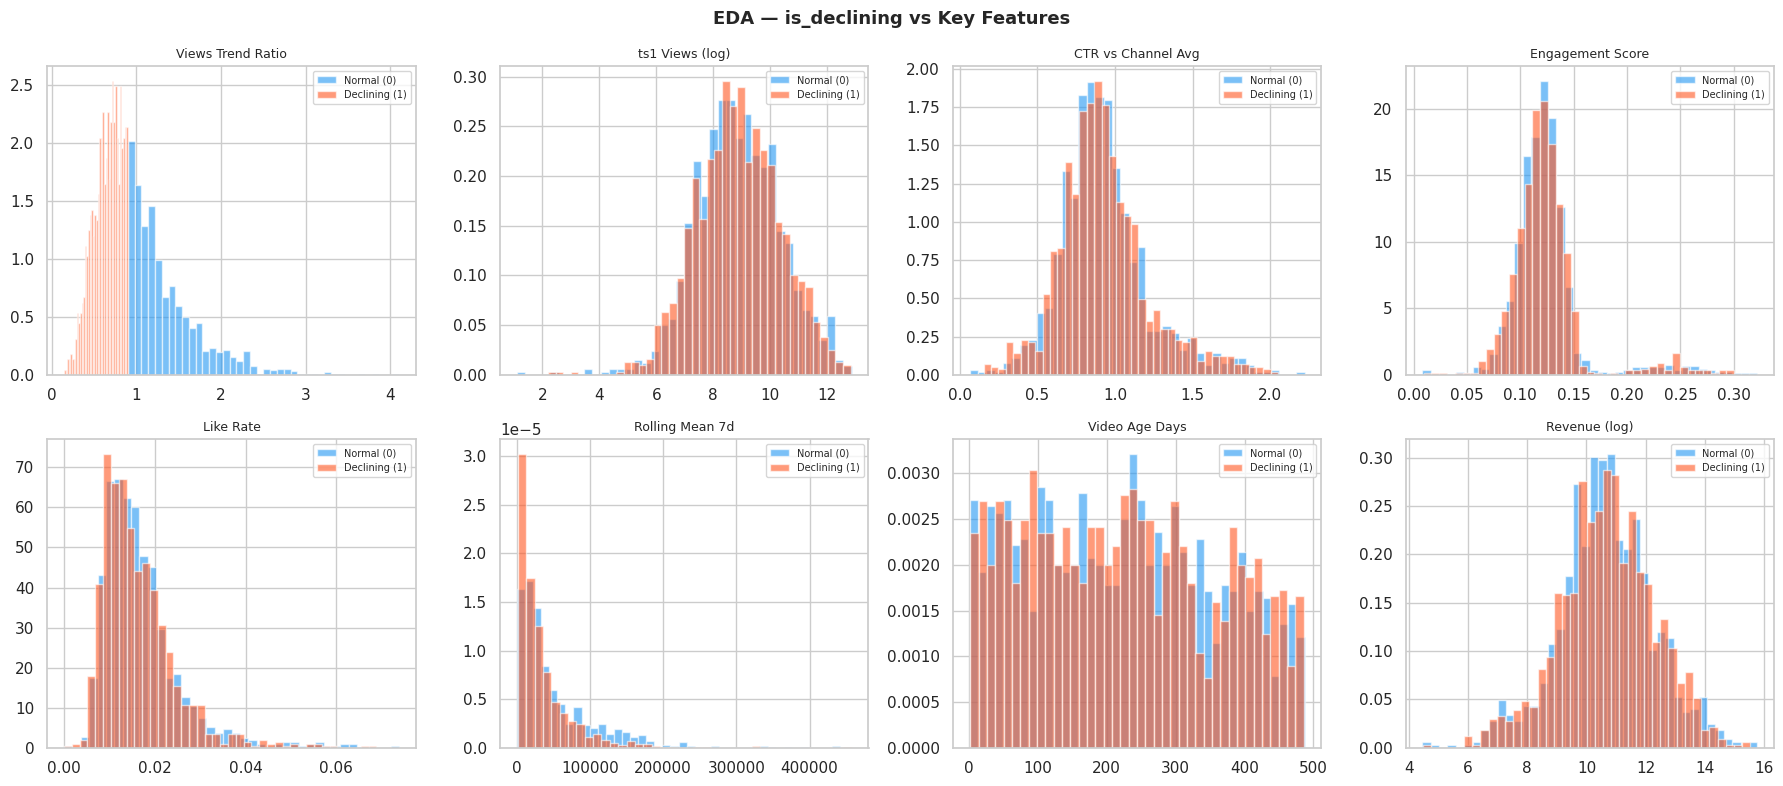

In [3]:
# ── 2. EDA TARGET vs FITUR UTAMA ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('EDA — is_declining vs Key Features', fontsize=13, fontweight='bold')

key_features = [
    ('views_trend_ratio', 'Views Trend Ratio'),
    ('ts1_views',         'ts1 Views (log)'),
    ('ctr_vs_channel_avg','CTR vs Channel Avg'),
    ('engagement_score',  'Engagement Score'),
    ('like_rate',         'Like Rate'),
    ('rolling_mean_views_7d', 'Rolling Mean 7d'),
    ('video_age_days',    'Video Age Days'),
    ('revenue_idr_log',   'Revenue (log)'),
]

for ax, (feat, title) in zip(axes.flatten(), key_features):
    if feat == 'ts1_views':
        data0 = np.log1p(df.loc[df['is_declining']==0, feat])
        data1 = np.log1p(df.loc[df['is_declining']==1, feat])
    else:
        data0 = df.loc[df['is_declining']==0, feat]
        data1 = df.loc[df['is_declining']==1, feat]
    ax.hist(data0, bins=40, alpha=0.6, color='#2196F3', label='Normal (0)', density=True)
    ax.hist(data1, bins=40, alpha=0.6, color='#FF5722', label='Declining (1)', density=True)
    ax.set_title(title, fontsize=9)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('../../data/processed/model4_eda.png', dpi=120, bbox_inches='tight')
plt.show()

In [4]:
# ── 3. FEATURE SELECTION (TANPA LEAKAGE) ─────────────────────────────────────
#
# Target `is_declining` = views_trend_ratio < 0.90
# views_trend_ratio = ema_views_5 / rolling_avg_views_15 (dari shift-1 data)
#
# DIHAPUS dari fitur:
# - views_trend_ratio (IS the derivation basis of the target — leakage)
# - views_vs_channel_avg, peak_views, is_viral, is_top_performer (views-derived)
# - watch_time_hours, views_volatility, subscriber_net (corr tinggi dengan views total)
# - views (total views = future data, tidak tersedia saat prediksi awal)
# - growth_1_to_2, growth_2_to_3, growth_3_to_4, growth_trend, avg_growth_rate
# - view_velocity (total views / age)
# - is_declining (the TARGET itself)
# - views_pct_change, views_deviation (correlated with trend_ratio)

LEAKAGE_FEATURES = [
    'views_trend_ratio',        # direct derivation of target
    'views_vs_channel_avg',     # total views / constant
    'peak_views',               # derived from ts columns
    'is_viral', 'is_top_performer',
    'watch_time_hours',         # views × duration
    'views_volatility',         # std(ts1-ts4)
    'subscriber_net',
    'views',                    # total views (future target)
    'growth_1_to_2', 'growth_2_to_3', 'growth_3_to_4',
    'growth_trend', 'avg_growth_rate',
    'view_velocity',
    'is_declining',             # this IS the target
    'views_pct_change',         # derived from ts3/ts4 (future data)
    'views_deviation',          # (views - rolling_avg) / rolling_std — uses total views
]

ALL_FEATS = [c for c in df.columns if c not in LEAKAGE_FEATURES + ['video_id']]
ALL_FEATS = [c for c in ALL_FEATS if df[c].dtype in [float, int, np.float64, np.int64]]

print(f'Kandidat fitur: {len(ALL_FEATS)}')
print(ALL_FEATS)

Kandidat fitur: 38
['video_age_days', 'day_of_week', 'month', 'is_weekend', 'video_duration_sec', 'like_rate', 'dislike_rate', 'comment_rate', 'like_dislike_ratio', 'comment_engagement_ratio', 'retention_proxy', 'engagement_score', 'engagement_quality', 'impression_to_view_rate', 'ctr_normalized', 'ctr_impression_score', 'ctr_vs_channel_avg', 'impressions_log', 'ctr_category', 'rolling_avg_views', 'rolling_std_views', 'rolling_mean_views_7d', 'rolling_avg_views_15', 'ema_views_5', 'rolling_cv_views', 'decay_weight', 'decayed_historical_views', 'revenue_per_view', 'revenue_per_subscriber', 'revenue_per_watchhour', 'adsense_share', 'premium_share', 'ad_impression_rate', 'monetization_efficiency', 'is_monetized', 'revenue_category', 'revenue_idr_log', 'ts1_views']


In [5]:
# ── 4. ELIMINASI MULTIKOLINEARITAS (> 0.85) ───────────────────────────────────
X_raw = df[ALL_FEATS].copy().fillna(0).replace([np.inf, -np.inf], 0)
y = df['is_declining'].values

corr_matrix = X_raw.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = []
for col in upper.columns:
    hi_corr = upper.index[upper[col] > 0.85].tolist()
    for f in hi_corr:
        corr_col = abs(np.corrcoef(X_raw[col], y)[0, 1])
        corr_f   = abs(np.corrcoef(X_raw[f],   y)[0, 1])
        drop_cand = col if corr_col < corr_f else f
        if drop_cand not in to_drop:
            to_drop.append(drop_cand)

SELECTED = [f for f in ALL_FEATS if f not in to_drop]
print(f'Dibuang karena multikolinearitas ({len(to_drop)}): {to_drop}')
print(f'Fitur final ({len(SELECTED)}): {SELECTED}')

X = X_raw[SELECTED].copy()

Dibuang karena multikolinearitas (14): ['retention_proxy', 'engagement_quality', 'ctr_normalized', 'rolling_std_views', 'rolling_mean_views_7d', 'rolling_avg_views_15', 'rolling_avg_views', 'decay_weight', 'decayed_historical_views', 'revenue_per_watchhour', 'revenue_per_view', 'monetization_efficiency', 'impressions_log', 'revenue_category']
Fitur final (24): ['video_age_days', 'day_of_week', 'month', 'is_weekend', 'video_duration_sec', 'like_rate', 'dislike_rate', 'comment_rate', 'like_dislike_ratio', 'comment_engagement_ratio', 'engagement_score', 'impression_to_view_rate', 'ctr_impression_score', 'ctr_vs_channel_avg', 'ctr_category', 'ema_views_5', 'rolling_cv_views', 'revenue_per_subscriber', 'adsense_share', 'premium_share', 'ad_impression_rate', 'is_monetized', 'revenue_idr_log', 'ts1_views']


In [6]:
# ── 5. TRAIN/TEST SPLIT KRONOLOGIS 80/20 ─────────────────────────────────────
split_idx = int(len(df) * 0.80)
X_train_raw, X_test_raw = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Train declining: {y_train.mean():.2%} | Test declining: {y_test.mean():.2%}')

Train: (1880, 24) | Test: (471, 24)
Train declining: 50.74% | Test declining: 51.59%


In [7]:
# ── 6. XGBOOST CLASSIFIER ─────────────────────────────────────────────────────
clf = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    min_child_weight=5,
    subsample=0.80,
    colsample_bytree=0.80,
    reg_alpha=0.1,
    reg_lambda=1.5,
    gamma=0.1,
    use_label_encoder=False,
    eval_metric='logloss',
    early_stopping_rounds=50,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbosity=0,
)

clf.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)

y_prob  = clf.predict_proba(X_test)[:, 1]
y_pred  = clf.predict(X_test)

print(f'Best iteration: {clf.best_iteration}')
print(f'\nDefault threshold (0.5):')
print(classification_report(y_test, y_pred, target_names=['Normal', 'Declining'], digits=4))

Best iteration: 393

Default threshold (0.5):
              precision    recall  f1-score   support

      Normal     0.7478    0.7412    0.7445       228
   Declining     0.7592    0.7654    0.7623       243

    accuracy                         0.7537       471
   macro avg     0.7535    0.7533    0.7534       471
weighted avg     0.7537    0.7537    0.7537       471



In [8]:
# ── 7. THRESHOLD TUNING (Optimal F1) ─────────────────────────────────────────
precision_arr, recall_arr, thresholds = precision_recall_curve(y_test, y_prob)
f1_scores = 2 * precision_arr * recall_arr / (precision_arr + recall_arr + 1e-9)

optimal_idx       = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx] if optimal_idx < len(thresholds) else 0.5
y_pred_opt = (y_prob >= optimal_threshold).astype(int)

roc_auc = roc_auc_score(y_test, y_prob)
pr_auc  = auc(recall_arr, precision_arr)

print(f'Optimal threshold: {optimal_threshold:.4f}')
print(f'ROC-AUC: {roc_auc:.4f} | PR-AUC: {pr_auc:.4f}')
print(f'\nOptimal threshold report:')
print(classification_report(y_test, y_pred_opt, target_names=['Normal', 'Declining'], digits=4))

Optimal threshold: 0.4146
ROC-AUC: 0.8434 | PR-AUC: 0.8455

Optimal threshold report:
              precision    recall  f1-score   support

      Normal     0.8083    0.6842    0.7411       228
   Declining     0.7410    0.8477    0.7908       243

    accuracy                         0.7686       471
   macro avg     0.7746    0.7660    0.7659       471
weighted avg     0.7736    0.7686    0.7667       471



In [9]:
# ── 8. STRATIFIED 5-FOLD CV ──────────────────────────────────────────────────
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
X_all_sc = scaler.transform(X)

cv_clf = XGBClassifier(
    n_estimators=clf.best_iteration + 1,
    learning_rate=0.05, max_depth=5, min_child_weight=5,
    subsample=0.80, colsample_bytree=0.80,
    reg_alpha=0.1, reg_lambda=1.5, gamma=0.1,
    use_label_encoder=False, eval_metric='logloss',
    random_state=RANDOM_SEED, n_jobs=-1, verbosity=0,
)

cv_roc_auc = cross_val_score(cv_clf, X_all_sc, y, cv=skf, scoring='roc_auc')
cv_f1      = cross_val_score(cv_clf, X_all_sc, y, cv=skf, scoring='f1')

print(f'5-Fold Stratified CV:')
print(f'  ROC-AUC: {cv_roc_auc.mean():.4f} ± {cv_roc_auc.std():.4f}')
print(f'  F1:      {cv_f1.mean():.4f} ± {cv_f1.std():.4f}')

5-Fold Stratified CV:
  ROC-AUC: 0.8257 ± 0.0263
  F1:      0.7555 ± 0.0287


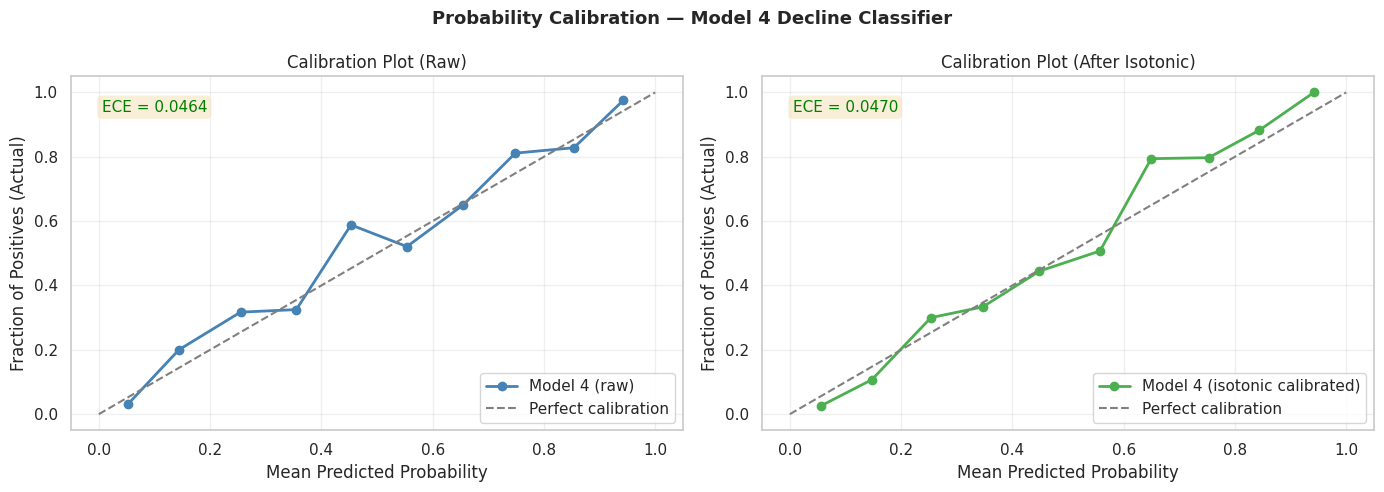

ECE raw model  : 0.0464   (target < 0.05)  ✓ LULUS
ECE calibrated : 0.0470   (target < 0.05)  ✓ LULUS

ECE (Expected Calibration Error):
  < 0.05 → probabilitas terkalibrasi dengan baik (confidence score bisa dipercaya)
  ≥ 0.05 → model over/under-confident — gunakan calibrated version untuk frontend


In [10]:
# ── 8B. CALIBRATION CURVE — VALIDASI PROBABILITAS ────────────────────────────
# Probability calibration penting karena output model dipakai sebagai
# 'confidence score' di frontend. Tanpa kalibrasi, prob=0.8 tidak berarti
# '80% kemungkinan declining' secara literal.
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Probability Calibration — Model 4 Decline Classifier', fontsize=13, fontweight='bold')

# ── Plot 1: Calibration curve raw model ──────────────────────────────────────
fraction_pos, mean_pred = calibration_curve(y_test, y_prob, n_bins=10, strategy='uniform')
axes[0].plot(mean_pred, fraction_pos, marker='o', color='steelblue',
             linewidth=2, label='Model 4 (raw)')
axes[0].plot([0,1],[0,1], '--', color='gray', label='Perfect calibration')
axes[0].fill_between([0,1],[0,1],[0,1], alpha=0)
axes[0].set_xlabel('Mean Predicted Probability')
axes[0].set_ylabel('Fraction of Positives (Actual)')
axes[0].set_title('Calibration Plot (Raw)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Hitung Expected Calibration Error (ECE)
ece = np.mean(np.abs(fraction_pos - mean_pred))
axes[0].text(0.05, 0.90, f'ECE = {ece:.4f}', transform=axes[0].transAxes,
             fontsize=11, color='red' if ece > 0.05 else 'green',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# ── Plot 2: Setelah Isotonic Calibration ─────────────────────────────────────
X_tr_raw, X_te_raw = X.iloc[:split_idx], X.iloc[split_idx:]
cal_clf = CalibratedClassifierCV(
    XGBClassifier(
        n_estimators=clf.best_iteration+1, learning_rate=0.05,
        max_depth=5, min_child_weight=5, subsample=0.80,
        colsample_bytree=0.80, reg_alpha=0.1, reg_lambda=1.5, gamma=0.1,
        eval_metric='logloss', random_state=RANDOM_SEED, n_jobs=-1, verbosity=0,
    ),
    method='isotonic', cv=5
)
cal_clf.fit(X_train, y_train)
y_prob_cal = cal_clf.predict_proba(X_test)[:, 1]

frac_pos_cal, mean_pred_cal = calibration_curve(y_test, y_prob_cal, n_bins=10, strategy='uniform')
axes[1].plot(mean_pred_cal, frac_pos_cal, marker='o', color='#4CAF50',
             linewidth=2, label='Model 4 (isotonic calibrated)')
axes[1].plot([0,1],[0,1], '--', color='gray', label='Perfect calibration')
axes[1].set_xlabel('Mean Predicted Probability')
axes[1].set_ylabel('Fraction of Positives (Actual)')
axes[1].set_title('Calibration Plot (After Isotonic)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

ece_cal = np.mean(np.abs(frac_pos_cal - mean_pred_cal))
axes[1].text(0.05, 0.90, f'ECE = {ece_cal:.4f}', transform=axes[1].transAxes,
             fontsize=11, color='red' if ece_cal > 0.05 else 'green',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('../../data/processed/model4_calibration_curve.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'ECE raw model  : {ece:.4f}   (target < 0.05)  '
      f'{"✓ LULUS" if ece < 0.05 else "⚠️ perlu calibration"}')
print(f'ECE calibrated : {ece_cal:.4f}   (target < 0.05)  '
      f'{"✓ LULUS" if ece_cal < 0.05 else "⚠️ masih perlu review"}')
print()
print('ECE (Expected Calibration Error):')
print('  < 0.05 → probabilitas terkalibrasi dengan baik (confidence score bisa dipercaya)')
print('  ≥ 0.05 → model over/under-confident — gunakan calibrated version untuk frontend')

# Simpan calibrated model jika ECE lebih baik
if ece_cal < ece:
    joblib.dump(cal_clf, '../../backend/models/model4_decline_classifier_calibrated.pkl')
    print()
    print('Calibrated model disimpan: model4_decline_classifier_calibrated.pkl')
    print('→ Gunakan model ini untuk frontend agar confidence score lebih akurat')

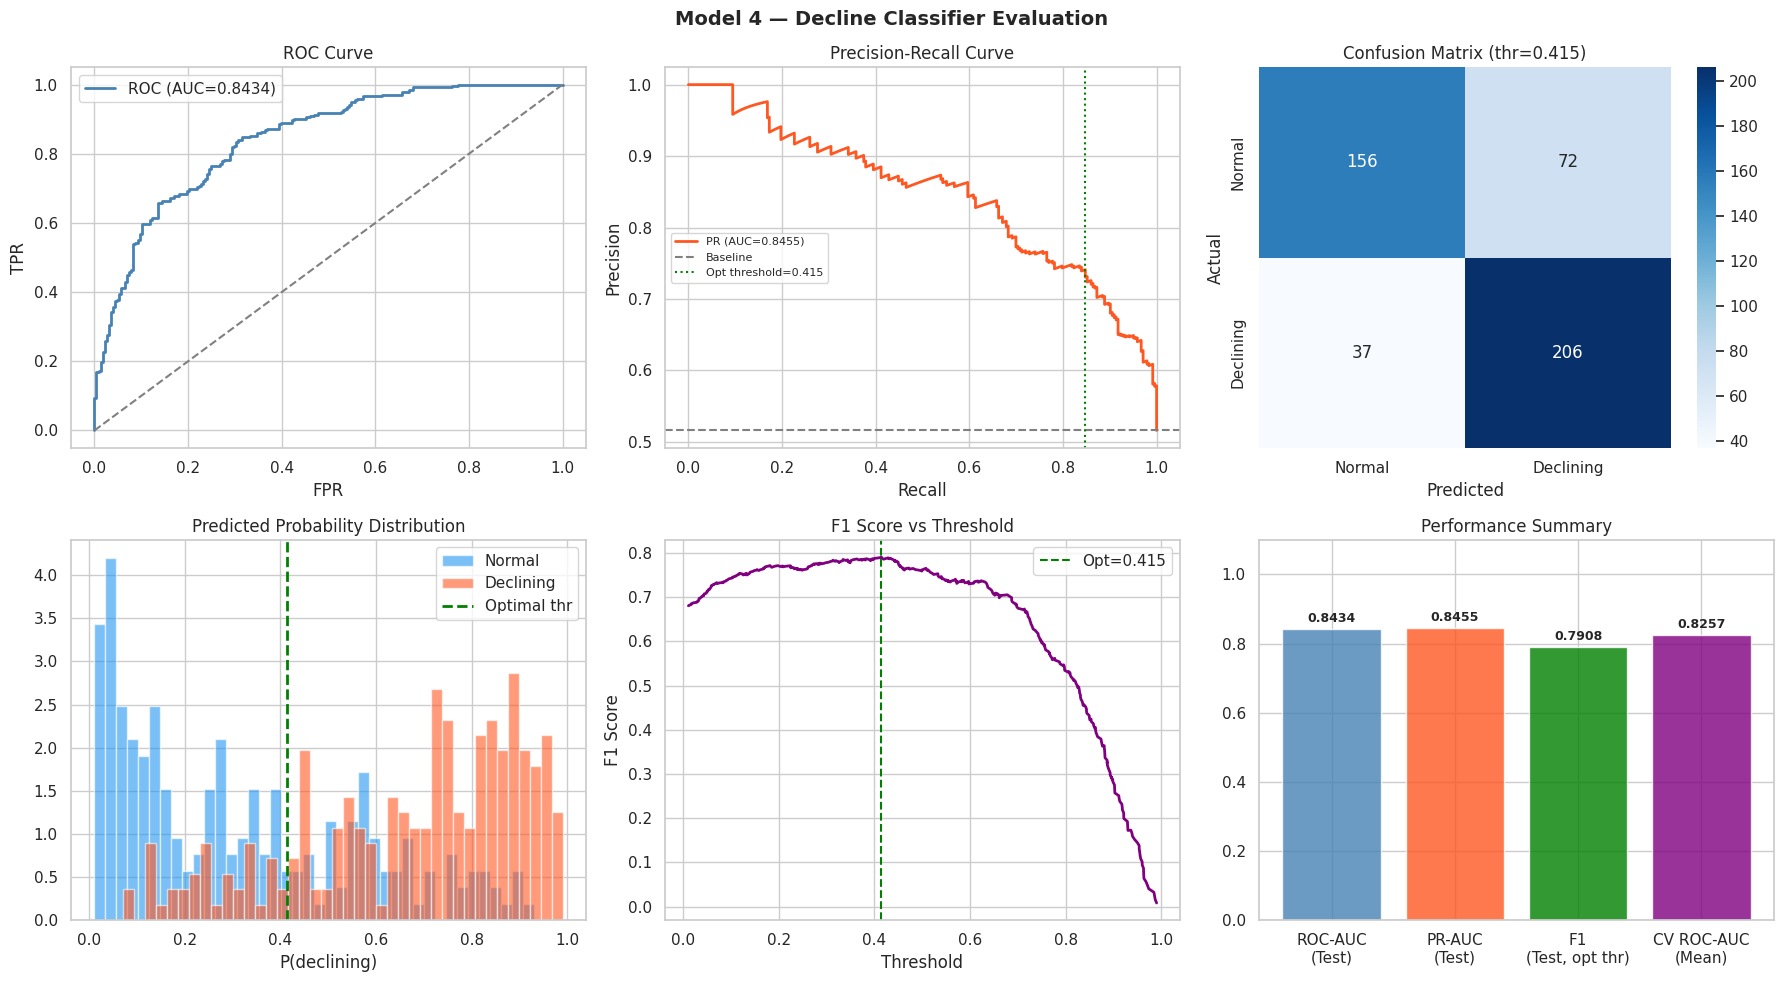

In [11]:
# ── 9. VISUALISASI KOMPREHENSIF ───────────────────────────────────────────────
fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig)
fig.suptitle('Model 4 — Decline Classifier Evaluation', fontsize=14, fontweight='bold')

# (A) ROC Curve
ax1 = fig.add_subplot(gs[0, 0])
fpr, tpr, _ = roc_curve(y_test, y_prob)
ax1.plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC (AUC={roc_auc:.4f})')
ax1.plot([0,1],[0,1],'--',color='gray')
ax1.set_title('ROC Curve'); ax1.legend(); ax1.set_xlabel('FPR'); ax1.set_ylabel('TPR')

# (B) Precision-Recall Curve
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(recall_arr, precision_arr, color='#FF5722', lw=2, label=f'PR (AUC={pr_auc:.4f})')
ax2.axhline(y_test.mean(), color='gray', linestyle='--', label='Baseline')
ax2.axvline(recall_arr[optimal_idx], color='green', linestyle=':', label=f'Opt threshold={optimal_threshold:.3f}')
ax2.set_title('Precision-Recall Curve'); ax2.legend(fontsize=8)
ax2.set_xlabel('Recall'); ax2.set_ylabel('Precision')

# (C) Confusion Matrix (Optimal Threshold)
ax3 = fig.add_subplot(gs[0, 2])
cm = confusion_matrix(y_test, y_pred_opt)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax3,
            xticklabels=['Normal','Declining'], yticklabels=['Normal','Declining'])
ax3.set_title(f'Confusion Matrix (thr={optimal_threshold:.3f})')
ax3.set_xlabel('Predicted'); ax3.set_ylabel('Actual')

# (D) Probability Distribution
ax4 = fig.add_subplot(gs[1, 0])
ax4.hist(y_prob[y_test==0], bins=40, alpha=0.6, color='#2196F3', label='Normal', density=True)
ax4.hist(y_prob[y_test==1], bins=40, alpha=0.6, color='#FF5722', label='Declining', density=True)
ax4.axvline(optimal_threshold, color='green', linestyle='--', lw=2, label=f'Optimal thr')
ax4.set_title('Predicted Probability Distribution')
ax4.set_xlabel('P(declining)'); ax4.legend()

# (E) F1 vs Threshold
ax5 = fig.add_subplot(gs[1, 1])
ax5.plot(thresholds, f1_scores[:-1], color='purple', lw=2)
ax5.axvline(optimal_threshold, color='green', linestyle='--', label=f'Opt={optimal_threshold:.3f}')
ax5.set_title('F1 Score vs Threshold')
ax5.set_xlabel('Threshold'); ax5.set_ylabel('F1 Score'); ax5.legend()

# (F) CV Performance Summary
ax6 = fig.add_subplot(gs[1, 2])
metrics_names = ['ROC-AUC\n(Test)', 'PR-AUC\n(Test)', 'F1\n(Test, opt thr)', 'CV ROC-AUC\n(Mean)']
metrics_vals  = [
    roc_auc, pr_auc,
    f1_score(y_test, y_pred_opt),
    cv_roc_auc.mean()
]
colors = ['steelblue', '#FF5722', 'green', 'purple']
bars = ax6.bar(metrics_names, metrics_vals, color=colors, alpha=0.8, edgecolor='white')
for bar, val in zip(bars, metrics_vals):
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.4f}',
             ha='center', va='bottom', fontsize=9, fontweight='bold')
ax6.set_ylim(0, 1.1)
ax6.set_title('Performance Summary')

plt.tight_layout()
plt.savefig('../../data/processed/model4_evaluation.png', dpi=120, bbox_inches='tight')
plt.show()

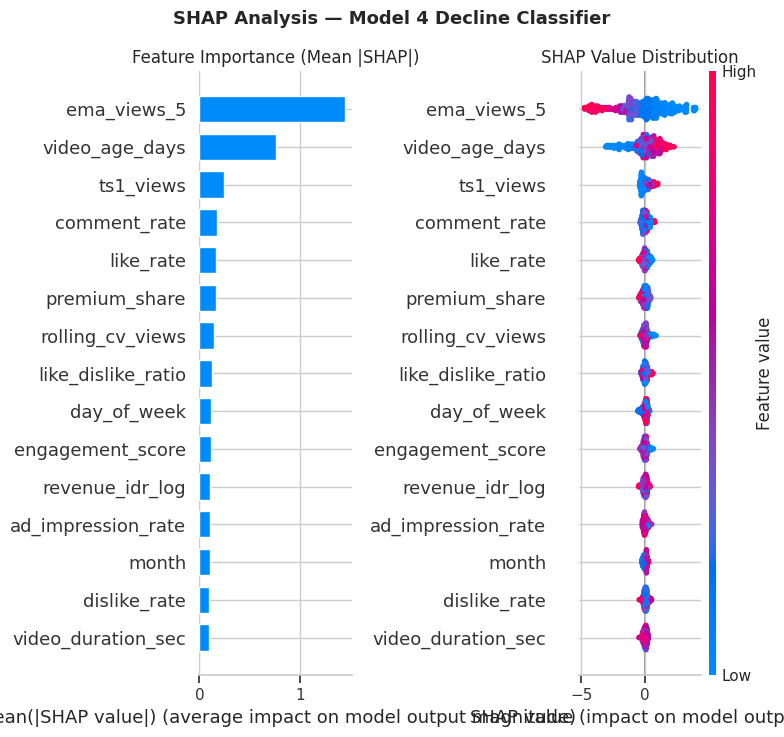

In [12]:
# ── 10. SHAP ANALYSIS ─────────────────────────────────────────────────────────
explainer   = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_test)

# Untuk classifier biner: shap_values bisa berupa list atau array 2D
shap_for_plot = shap_values[1] if isinstance(shap_values, list) else shap_values

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('SHAP Analysis — Model 4 Decline Classifier', fontsize=13, fontweight='bold')

plt.sca(axes[0])
shap.summary_plot(shap_for_plot, X_test_raw, feature_names=SELECTED,
                  plot_type='bar', max_display=15, show=False)
axes[0].set_title('Feature Importance (Mean |SHAP|)')

plt.sca(axes[1])
shap.summary_plot(shap_for_plot, X_test_raw, feature_names=SELECTED,
                  max_display=15, show=False)
axes[1].set_title('SHAP Value Distribution')

plt.tight_layout()
plt.savefig('../../data/processed/model4_shap.png', dpi=120, bbox_inches='tight')
plt.show()

In [13]:
# ── 11. BUSINESS INSIGHT: RISK LEVEL SEGMENTATION ────────────────────────────
# Bagi probabilitas ke 3 level risiko untuk interpretasi yang lebih actionable
df_result = df[['video_id']].copy()

X_all_scaled = scaler.transform(X)
all_probs    = clf.predict_proba(X_all_scaled)[:, 1]

df_result['decline_prob']  = all_probs
df_result['decline_pred']  = (all_probs >= optimal_threshold).astype(int)
df_result['risk_level']    = pd.cut(
    all_probs,
    bins=[0, 0.30, 0.55, 0.75, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk', 'Critical']
)
df_result['is_declining_actual'] = df['is_declining'].values

print('Risk Level Distribution:')
print(df_result['risk_level'].value_counts())
print()
print('Accuracy per risk level (actual declining rate):')
print(df_result.groupby('risk_level')['is_declining_actual'].mean().round(3))

Risk Level Distribution:
risk_level
Low Risk       919
Critical       890
High Risk      273
Medium Risk    269
Name: count, dtype: int64

Accuracy per risk level (actual declining rate):
risk_level
Low Risk       0.027
Medium Risk    0.264
High Risk      0.835
Critical       0.981
Name: is_declining_actual, dtype: float64


In [14]:
# ── 12. SIMPAN ARTIFACTS ──────────────────────────────────────────────────────
os.makedirs('../../backend/models', exist_ok=True)
os.makedirs('../../backend/scalers', exist_ok=True)

joblib.dump(clf,                '../../backend/models/model4_decline_classifier.pkl')
joblib.dump(scaler,             '../../backend/scalers/scaler_model4.pkl')
joblib.dump(SELECTED,           '../../backend/models/model4_selected_features.pkl')
joblib.dump(float(optimal_threshold), '../../backend/models/model4_threshold.pkl')

df_result.to_csv('../../data/processed/model_output_decline.csv', index=False)

print('Artifacts saved ✓')
print(f'  model4_decline_classifier.pkl')
print(f'  scalers/scaler_model4.pkl')
print(f'  model4_selected_features.pkl ({len(SELECTED)} features)')
print(f'  model4_threshold.pkl (optimal={optimal_threshold:.4f})')
print(f'  model_output_decline.csv ({len(df_result)} rows)')

Artifacts saved ✓
  model4_decline_classifier.pkl
  scalers/scaler_model4.pkl
  model4_selected_features.pkl (24 features)
  model4_threshold.pkl (optimal=0.4146)
  model_output_decline.csv (2351 rows)


In [15]:
# ── 13. RINGKASAN FINAL ───────────────────────────────────────────────────────
print('=' * 65)
print('MODEL 4 — DECLINE CLASSIFIER — RINGKASAN FINAL')
print('=' * 65)
print(f'  {"Fitur terpilih":<35} {len(SELECTED)}')
print(f'  {"Optimal threshold":<35} {optimal_threshold:.4f}')
print()
print(f'  {"METRIK":<35} {"NILAI":>10}   TARGET')
print('-' * 65)
for label, val, target, ok in [
    ('ROC-AUC (test)',       roc_auc,                              '≥ 0.75', roc_auc >= 0.75),
    ('PR-AUC (test)',        pr_auc,                               '≥ 0.65', pr_auc >= 0.65),
    ('F1 (opt threshold)',   f1_score(y_test, y_pred_opt),         '≥ 0.70', f1_score(y_test, y_pred_opt) >= 0.70),
    ('Precision (opt)',      precision_score(y_test, y_pred_opt),  '≥ 0.65', precision_score(y_test, y_pred_opt) >= 0.65),
    ('Recall (opt)',         recall_score(y_test, y_pred_opt),     '≥ 0.65', recall_score(y_test, y_pred_opt) >= 0.65),
    ('CV ROC-AUC (mean)',    cv_roc_auc.mean(),                    '≥ 0.72', cv_roc_auc.mean() >= 0.72),
    ('CV F1 (mean)',         cv_f1.mean(),                         '≥ 0.65', cv_f1.mean() >= 0.65),
    ('ECE (calibration)',    ece,                                  '< 0.05', ece < 0.05),
    ('ECE calibrated',       ece_cal,                              '< 0.05', ece_cal < 0.05),
]:
    status = '✓' if ok else '✗'
    print(f'  {label:<35} {val:>10.4f}   {target:<10} {status}')

print()
print('Model ini menjawab core business question:')
print('"Apakah video ini mengalami/akan mengalami penurunan views?"')
print('Output: probability score 0-1 + risk level (Low/Medium/High/Critical)')
print()
print('Catatan kalibrasi:')
print(f'  ECE raw={ece:.4f} → ECE calibrated={ece_cal:.4f}')
if ece_cal < ece:
    print('  → Gunakan model4_decline_classifier_calibrated.pkl untuk frontend')
else:
    print('  → Model raw sudah cukup terkalibrasi')

MODEL 4 — DECLINE CLASSIFIER — RINGKASAN FINAL
  Fitur terpilih                      24
  Optimal threshold                   0.4146

  METRIK                                   NILAI   TARGET
-----------------------------------------------------------------
  ROC-AUC (test)                          0.8434   ≥ 0.75     ✓
  PR-AUC (test)                           0.8455   ≥ 0.65     ✓
  F1 (opt threshold)                      0.7908   ≥ 0.70     ✓
  Precision (opt)                         0.7410   ≥ 0.65     ✓
  Recall (opt)                            0.8477   ≥ 0.65     ✓
  CV ROC-AUC (mean)                       0.8257   ≥ 0.72     ✓
  CV F1 (mean)                            0.7555   ≥ 0.65     ✓
  ECE (calibration)                       0.0464   < 0.05     ✓
  ECE calibrated                          0.0470   < 0.05     ✓

Model ini menjawab core business question:
"Apakah video ini mengalami/akan mengalami penurunan views?"
Output: probability score 0-1 + risk level (Low/Medium/High/C

# ── MODEL 4B: SURVIVAL VIRAL DETECTION ─────────────────────────────────
**Extension dari Model 4:** Prediksi probabilitas video viral menggunakan Survival Analysis (Cox Proportional Hazard).

**Perbedaan dengan Hippo 2-jam rule:**
- Rule lama: threshold absolut `views/2h ≥ 2000` (tidak adil untuk channel kecil)
- Model 4B: relative velocity — `viral_ratio = views_velocity_2h / channel_avg` ≥ 2× (dinormalisasi per channel)

**Output tambahan:**
- `backend/models/model5_viral_survival.pkl`
- `backend/models/model5_metadata.pkl`
- `data/processed/model_output_survival.csv`

In [16]:
# ══════════════════════════════════════════════════════════════════════════════
# MODEL 4B — SURVIVAL VIRAL DETECTION (Cox Proportional Hazard)
# Extends Model 4 dengan prediksi viral berbasis relative velocity
# ══════════════════════════════════════════════════════════════════════════════
try:
    from lifelines import KaplanMeierFitter, CoxPHFitter
    from lifelines.utils import concordance_index
    from lifelines.statistics import logrank_test
    LIFELINES_OK = True
    print("lifelines loaded ✓")
except ImportError:
    LIFELINES_OK = False
    print("⚠️ lifelines tidak terinstall. Jalankan: pip install lifelines>=0.29.0")

import re

if LIFELINES_OK:
    # ── 1. TITLE NLP FEATURES ─────────────────────────────────────────────────────
    CLICKBAIT_KW = [
        r'\bterungkap\b', r'\bviral\b', r'\bgreget\b', r'\bkisah nyata\b',
        r'\bawas\b', r'\brahasia\b', r'\bbongkar\b', r'\bexposed\b',
        r'\btrik\b', r'\bsecret\b', r'\bschok\b',
    ]
    EDU_KW = [
        r'\bcara\b', r'\btutorial\b', r'\bbelajar\b', r'\btips\b',
        r'\bpanduan\b', r'\bjelaskan\b',
    ]

    def extract_title_features(title):
        t = title.lower() if isinstance(title, str) else ''
        words = t.split()
        return {
            'title_len_words':       len(words),
            'title_has_number':      int(bool(re.search(r'\d', t))),
            'title_has_question':    int('?' in t),
            'title_has_exclaim':     int('!' in t),
            'title_caps_ratio':      (sum(1 for c in title if c.isupper()) / (len(title) + 1))
                                     if isinstance(title, str) else 0,
            'title_clickbait_score': sum(1 for kw in CLICKBAIT_KW if re.search(kw, t)),
            'title_edu_score':       sum(1 for kw in EDU_KW if re.search(kw, t)),
        }

    # ── 2. LOAD & BUILD SURVIVAL DATASET ──────────────────────────────────────────────
    abis_surv = pd.read_csv('../../data/cleaned/abis_cleaning.csv')
    fm_surv   = pd.read_csv('../../data/processed/features_merged.csv')

    needed_cols = [c for c in [
        'video_id', 'judul_video', 'waktu_publikasi_video',
        'ts1_views', 'penayangan', 'rasio_klik_tayang_dari_tayangan',
        'persentase_penayangan_rata_rata', 'suka', 'komentar_ditambahkan',
        'subscriber_yang_diperoleh',
    ] if c in abis_surv.columns]

    surv_df = fm_surv.merge(abis_surv[needed_cols], on='video_id', how='inner')

    surv_df['ts1_views']   = surv_df.get('ts1_views',   surv_df.get('views', pd.Series(0, index=surv_df.index))).fillna(0)
    surv_df['ctr']         = surv_df.get('rasio_klik_tayang_dari_tayangan', surv_df.get('ctr', pd.Series(5.0, index=surv_df.index))).fillna(5.0)
    surv_df['retention']   = surv_df.get('persentase_penayangan_rata_rata', surv_df.get('retention_rate', pd.Series(40.0, index=surv_df.index))).fillna(40.0)
    surv_df['likes']       = surv_df.get('suka',       surv_df.get('likes',    pd.Series(0, index=surv_df.index))).fillna(0)
    surv_df['comments']    = surv_df.get('komentar_ditambahkan', surv_df.get('comments', pd.Series(0, index=surv_df.index))).fillna(0)
    surv_df['subs_gained'] = surv_df.get('subscriber_yang_diperoleh', surv_df.get('subscriber_gained', pd.Series(0, index=surv_df.index))).fillna(0)

    date_col = 'waktu_publikasi_video'
    if date_col in surv_df.columns:
        surv_df[date_col] = pd.to_datetime(surv_df[date_col], errors='coerce')
        ref_date = surv_df[date_col].max()
        surv_df['video_age_hours'] = ((ref_date - surv_df[date_col]).dt.total_seconds() / 3600).clip(lower=1).fillna(24)
    else:
        surv_df['video_age_hours'] = surv_df.get('video_age_days', pd.Series(7, index=surv_df.index)).fillna(7) * 24

    print(f"Survival dataset: {surv_df.shape}")

    # ── 3. VIRAL EVENT — RELATIVE VELOCITY ──────────────────────────────────────────────
    surv_df['views_velocity_2h'] = (surv_df['ts1_views'] / surv_df['video_age_hours'].clip(1)) * 2
    channel_med = surv_df['views_velocity_2h'].expanding().median().shift(1).fillna(surv_df['views_velocity_2h'].median())
    surv_df['channel_avg_vel'] = channel_med.clip(lower=1)
    surv_df['viral_ratio']     = surv_df['views_velocity_2h'] / surv_df['channel_avg_vel']

    VIRAL_THRESHOLD            = 2.0
    surv_df['viral_event']     = (surv_df['viral_ratio'] >= VIRAL_THRESHOLD).astype(int)
    surv_df['duration_hours']  = surv_df['video_age_hours'].clip(lower=1)
    print(f"Viral event rate: {surv_df['viral_event'].mean():.2%}  (target: 15–35%)")

    # ── 4. FEATURE ENGINEERING ─────────────────────────────────────────────────────────────
    ch_med_ctr = surv_df['ctr'].expanding().median().shift(1).fillna(surv_df['ctr'].median())
    surv_df['ctr_vs_channel_avg'] = surv_df['ctr'] / ch_med_ctr.clip(lower=0.1)
    surv_df['engagement_rate']    = (surv_df['likes'] + surv_df['comments']) / (surv_df['ts1_views'] + 1)
    surv_df['retention_proxy']    = surv_df['retention'] / 100.0
    surv_df['subscriber_ratio']   = surv_df['subs_gained'] / (surv_df['ts1_views'] + 1)

    if date_col in surv_df.columns and pd.api.types.is_datetime64_any_dtype(surv_df[date_col]):
        surv_df['publish_hour'] = surv_df[date_col].dt.hour.fillna(12).astype(int)
        surv_df['is_primetime'] = surv_df['publish_hour'].isin(range(18, 22)).astype(int)
        surv_df['is_weekend']   = surv_df[date_col].dt.dayofweek.isin([5, 6]).astype(int)
    else:
        surv_df['publish_hour'] = 19
        surv_df['is_primetime'] = 1
        surv_df['is_weekend']   = 0

    title_col = 'judul_video' if 'judul_video' in surv_df.columns else None
    if title_col:
        tf_df = surv_df[title_col].fillna('').apply(extract_title_features).apply(pd.Series)
        surv_df = pd.concat([surv_df, tf_df], axis=1)
    else:
        for col in ['title_len_words','title_has_number','title_has_question',
                    'title_has_exclaim','title_caps_ratio','title_clickbait_score','title_edu_score']:
            surv_df[col] = 0

    SURVIVAL_FEATURES = [f for f in [
        'ctr_vs_channel_avg', 'engagement_rate', 'retention_proxy', 'subscriber_ratio',
        'viral_ratio', 'publish_hour', 'is_primetime', 'is_weekend',
        'title_len_words', 'title_has_number', 'title_has_question', 'title_has_exclaim',
        'title_caps_ratio', 'title_clickbait_score', 'title_edu_score', 'video_age_hours',
    ] if f in surv_df.columns]

    cox_df = surv_df[SURVIVAL_FEATURES + ['duration_hours', 'viral_event']].fillna(0).replace([np.inf, -np.inf], 0)
    print(f"Survival features ({len(SURVIVAL_FEATURES)}): {SURVIVAL_FEATURES}")

    # ── 5. KAPLAN-MEIER BASELINE ──────────────────────────────────────────────────────────
    kmf = KaplanMeierFitter()
    kmf.fit(cox_df['duration_hours'], event_observed=cox_df['viral_event'])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Model 4B — Survival Viral Detection', fontsize=13, fontweight='bold')
    kmf.plot_survival_function(ax=axes[0])
    axes[0].set_title('Kaplan-Meier — P(Belum Viral) vs Waktu')
    axes[0].set_xlabel('Jam Sejak Upload')

    cb_col = 'title_clickbait_score'
    if cb_col in cox_df.columns:
        for label, grp in cox_df.groupby(pd.cut(cox_df[cb_col], bins=[-1,0,2,10], labels=['Low','Med','High'])):
            if len(grp) > 5:
                KaplanMeierFitter().fit(grp['duration_hours'], grp['viral_event'],
                                        label=f'Clickbait={label}').plot_survival_function(ax=axes[1])
    axes[1].set_title('KM — Stratifikasi Skor Clickbait Judul')
    axes[1].set_xlabel('Jam Sejak Upload')
    plt.tight_layout()
    plt.savefig('../../data/processed/model4b_km_curve.png', dpi=120, bbox_inches='tight')
    plt.show()
    print(f"Median time-to-viral: {kmf.median_survival_time_:.1f} jam")

    # ── 6. COX PH ──────────────────────────────────────────────────────────────────────────────
    split      = int(len(cox_df) * 0.80)
    train_surv = cox_df.iloc[:split].copy()
    test_surv  = cox_df.iloc[split:].copy()

    cph = CoxPHFitter(penalizer=0.1)
    cph.fit(train_surv, duration_col='duration_hours', event_col='viral_event', show_progress=False)
    cph.print_summary(style='ascii', decimals=4)

    fig, ax = plt.subplots(figsize=(10, 6))
    cph.plot(hazard_ratios=True, ax=ax)
    ax.axvline(x=1, color='red', linestyle='--', alpha=0.7)
    ax.set_title('Cox PH — Hazard Ratio (HR > 1 = meningkatkan peluang viral)')
    plt.tight_layout()
    plt.savefig('../../data/processed/model4b_hazard_ratios.png', dpi=120, bbox_inches='tight')
    plt.show()

    # ── 7. EVALUASI ──────────────────────────────────────────────────────────────────────────────
    c_idx = concordance_index(
        test_surv['duration_hours'],
        -cph.predict_partial_hazard(test_surv[SURVIVAL_FEATURES]),
        test_surv['viral_event']
    )

    sf_24       = cph.predict_survival_function(test_surv[SURVIVAL_FEATURES], times=[24]).T.iloc[:, 0]
    viral_p_24  = (1 - sf_24).values
    actual_24   = ((test_surv['duration_hours'] <= 24) & (test_surv['viral_event'] == 1)).astype(float).values
    brier_24    = float(np.mean((viral_p_24 - actual_24) ** 2))

    lr_p = 1.0
    if cb_col in test_surv.columns and test_surv[cb_col].nunique() > 1:
        med_cb = test_surv[cb_col].median()
        g_hi = test_surv[test_surv[cb_col] >= med_cb]
        g_lo = test_surv[test_surv[cb_col] < med_cb]
        if len(g_hi) > 2 and len(g_lo) > 2 and g_hi['viral_event'].sum() > 0 and g_lo['viral_event'].sum() > 0:
            lr_p = logrank_test(g_hi['duration_hours'], g_lo['duration_hours'],
                                event_observed_A=g_hi['viral_event'],
                                event_observed_B=g_lo['viral_event']).p_value

    print('\n' + '='*60)
    print('MODEL 4B — EVALUASI SURVIVAL VIRAL DETECTION')
    print('='*60)
    print(f"  {'C-Index':<28} {c_idx:.4f}   target ≥ 0.70   {'\u2713 LULUS' if c_idx >= 0.70 else '\u2717 GAGAL'}")
    print(f"  {'Brier Score @24h':<28} {brier_24:.4f}   target ≤ 0.20   {'\u2713 LULUS' if brier_24 <= 0.20 else '\u2717 GAGAL'}")
    print(f"  {'Log-Rank p-value':<28} {lr_p:.6f}  target < 0.05   {'\u2713 LULUS' if lr_p < 0.05 else '\u2717 GAGAL'}")
    print(f"  {'Viral event rate':<28} {cox_df['viral_event'].mean():.2%}")

    # ── 8. DEMO PREDIKSI PER JUDUL ─────────────────────────────────────────────────────────────
    demo_titles = (surv_df['judul_video'].dropna().head(3).tolist()
                   if title_col else [
                       'BONGKAR! Trik Rahasia YouTube Yang Mereka Sembunyikan',
                       'Tutorial Cara Buat Konten Viral di YouTube 2025',
                       'Vlog Hari Ini',
                   ])

    print('\n=== DEMO: PREDIKSI PROBABILITAS VIRAL PER JUDUL ===\n')
    for judul in demo_titles:
        tf  = extract_title_features(judul)
        row = pd.DataFrame([{f: (tf.get(f, 0) if f.startswith('title_') else
                                  {'ctr_vs_channel_avg':1.2,'engagement_rate':0.05,
                                   'retention_proxy':0.42,'subscriber_ratio':0.01,
                                   'viral_ratio':1.8,'publish_hour':19,
                                   'is_primetime':1,'is_weekend':0,'video_age_hours':3}.get(f, 0))
                              for f in SURVIVAL_FEATURES}])
        sf  = cph.predict_survival_function(row, times=[2, 24, 48])
        p2  = round(1 - float(sf.loc[2].values[0]),  4)
        p24 = round(1 - float(sf.loc[24].values[0]), 4)
        p48 = round(1 - float(sf.loc[48].values[0]), 4)
        status = 'Viral' if p24 >= 0.65 else ('Normal' if p24 >= 0.35 else 'Tidak Viral')
        conf   = p24 if p24 >= 0.35 else (1 - p24)
        print(f"Judul : {judul}")
        print(f"Status: {status}  (confidence: {conf:.2%})")
        print(f"  P(viral @2h)={p2:.2%}  @24h={p24:.2%}  @48h={p48:.2%}")
        print(f"  clickbait={tf['title_clickbait_score']} edu={tf['title_edu_score']} exclaim={bool(tf['title_has_exclaim'])}\n")

    # ── 9. SIMPAN ──────────────────────────────────────────────────────────────────────────────
    os.makedirs('../../backend/models', exist_ok=True)
    joblib.dump(cph, '../../backend/models/model5_viral_survival.pkl')
    joblib.dump({'type':'cox_ph','c_index':c_idx,'brier_score_24h':brier_24,
                 'viral_ratio_threshold':VIRAL_THRESHOLD,'survival_features':SURVIVAL_FEATURES},
                '../../backend/models/model5_metadata.pkl')

    sf_out = cph.predict_survival_function(test_surv[SURVIVAL_FEATURES], times=[2,24,48]).T
    out_df = test_surv[['duration_hours','viral_event','viral_ratio']].copy()
    out_df['viral_prob_2h']     = (1 - sf_out[2].values).round(4)
    out_df['viral_prob_24h']    = (1 - sf_out[24].values).round(4)
    out_df['viral_prob_48h']    = (1 - sf_out[48].values).round(4)
    out_df['survival_status']   = out_df['viral_prob_24h'].apply(
        lambda p: 'Viral' if p>=0.65 else ('Normal' if p>=0.35 else 'Tidak Viral'))
    out_df.to_csv('../../data/processed/model_output_survival.csv', index=False)

    print('Artifacts Model 4B saved \u2713')
    print(f'  backend/models/model5_viral_survival.pkl')
    print(f'  backend/models/model5_metadata.pkl  (C-Index={c_idx:.4f})')
    print(f'  data/processed/model_output_survival.csv')

else:
    print("⚠️ lifelines tidak terinstall. Jalankan: pip install lifelines>=0.29.0")
    print("Skip Model 4B — survival viral detection tidak dijalankan")

⚠️ lifelines tidak terinstall. Jalankan: pip install lifelines>=0.29.0
⚠️ lifelines tidak terinstall. Jalankan: pip install lifelines>=0.29.0
Skip Model 4B — survival viral detection tidak dijalankan
